# 12 - Spatial-Domain Confound Ablation

**This notebook decides what the paper is allowed to claim.**

On Tomasov, the 61 spatial features (6% of the feature space) carry **55.3%** of the
model's importance mass, and the top 15 features are *all* spatial. In the original
submission the time-frequency domain was strongest and spatial was third. That inversion
appeared the moment the leak was removed - which is suspicious in a specific way.

## The hypothesis being tested

Five of the nine Tomasov classes come from **exactly one recording each**
(`construction`, `manipulation`, `openclose`, `regular`, `running`). For those classes
*recording identity is class identity*. Spatial descriptors summarise fibre geometry,
coupling and channel-to-channel energy structure - all of which are fixed properties of a
recording. So a model can score well by answering "which recording is this?" instead of
"what event is this?".

The blocked split cannot prevent that: it splits *within* each recording, so the
recording is present in train, val and test by construction.

## Four experiments, in order of how directly they test the hypothesis

1. **Leave-one-domain-out** - how much does each domain contribute?
2. **Recording-identity probe** - *the decisive test*. Fix the class, then ask the
   features to predict **which recording** a window came from. A domain that does this
   well is a recording fingerprint, whatever else it may also encode.
3. **Positional leakage check** - do spatial features correlate with the absolute locus
   index rather than with the event?
4. **Leave-one-recording-out, with and without spatial** - if spatial features are a
   fingerprint, removing them should *help* cross-recording generalisation.

## Reading the outcome

| Finding | What the paper says |
|---|---|
| Dropping spatial costs little | Concern dissolves; keep the current framing |
| Dropping spatial costs a lot **and** spatial predicts recording identity | The headline must become the non-spatial number, with the confound reported |
| Dropping spatial costs a lot but spatial does **not** predict recording identity | Spatial genuinely carries event information; report it as a finding |

In [1]:
import sys, json, time
from pathlib import Path
EXPERIMENT_DIR = Path(r"/mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Experiment")
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dasfe import config as C, fusion as F, evaluate as EV

sns.set_theme(style="whitegrid", context="notebook")

# ----------------------------- CONFIGURE ME -----------------------------
DATASETS   = ("tomasov", "cao")
MODEL      = "LightGBM"
STRATEGY   = "class_weight"     # fixed across all arms so only features vary
# The expensive sweeps (recording probe, LORO) are subsampled per class to keep
# runtime sane; the headline leave-one-domain-out arm uses everything.
PROBE_PER_CLASS = 4000
LORO_PER_CLASS  = 6000
# ------------------------------------------------------------------------

DOMAIN_SLICES = {"time": slice(0, 112), "freq": slice(112, 202),
                 "tf": slice(202, 941), "spatial": slice(941, 1002)}
SIGNAL_AGNOSTIC = slice(0, 941)     # time + freq + tf

def cols(*keep):
    idx = []
    for k in keep:
        sl = DOMAIN_SLICES[k]
        idx.extend(range(sl.start, sl.stop))
    return np.array(idx)

DATA = {}
for ds in DATASETS:
    d = F.load(C.results_dir(ds, "04_fusion"))
    d["split"] = d["manifest"]["split"].to_numpy()
    DATA[ds] = d
    print(f"{ds:8s} X {d['X'].shape}  classes {len(set(d['y']))}")

out_dir = C.results_dir("shared", "12_spatial_ablation")
print("output:", out_dir)

tomasov  X (172458, 1002)  classes 9
cao      X (15418, 1002)  classes 6
output: /mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Results/shared/12_spatial_ablation


## 1. Leave-one-domain-out

Same model, same balancing, same split. Only the feature columns change.

In [2]:
ARMS = {
    "all 1002 (reference)":      list(DOMAIN_SLICES),
    "no spatial (941)":          ["time", "freq", "tf"],
    "no time-frequency (263)":   ["time", "freq", "spatial"],
    "no time (890)":             ["freq", "tf", "spatial"],
    "no frequency (912)":        ["time", "tf", "spatial"],
    "spatial ONLY (61)":         ["spatial"],
    "time-frequency ONLY (739)": ["tf"],
}

lodo = []
for ds in DATASETS:
    d = DATA[ds]
    X, y, sp = d["X"], d["y"], d["split"]
    tr, te = sp == "train", sp == "test"
    print(f"\n=== {ds} ===")
    for name, keep in ARMS.items():
        c = cols(*keep)
        t0 = time.perf_counter()
        r = EV.fit_predict(MODEL, STRATEGY, X[tr][:, c], y[tr], X[te][:, c], y[te], C.SEED)
        m = r["metrics"]
        lodo.append({"dataset": ds, "arm": name, "n_features": len(c),
                     "accuracy": 100*m["accuracy"],
                     "balanced_accuracy": 100*m["balanced_accuracy"],
                     "f1_macro": 100*m["f1_macro"],
                     "train_seconds": round(m["train_seconds"], 1)})
        print(f"  {name:28s} {len(c):4d} feat  acc {100*m['accuracy']:6.2f}  "
              f"F1 {100*m['f1_macro']:6.2f}  ({time.perf_counter()-t0:.0f}s)", flush=True)

lodo = pd.DataFrame(lodo)
display(lodo.round(2))
lodo.to_csv(out_dir / "leave_one_domain_out.csv", index=False)


=== tomasov ===
  all 1002 (reference)         1002 feat  acc  90.83  F1  81.81  (626s)
  no spatial (941)              941 feat  acc  63.13  F1  62.13  (558s)
  no time-frequency (263)       263 feat  acc  90.77  F1  81.57  (142s)
  no time (890)                 890 feat  acc  90.87  F1  81.90  (534s)
  no frequency (912)            912 feat  acc  90.72  F1  81.72  (544s)
  spatial ONLY (61)              61 feat  acc  87.21  F1  75.56  (38s)
  time-frequency ONLY (739)     739 feat  acc  59.30  F1  58.98  (436s)

=== cao ===
  all 1002 (reference)         1002 feat  acc  99.06  F1  98.89  (43s)
  no spatial (941)              941 feat  acc  95.23  F1  93.75  (51s)
  no time-frequency (263)       263 feat  acc  98.56  F1  98.35  (12s)
  no time (890)                 890 feat  acc  98.89  F1  98.64  (38s)
  no frequency (912)            912 feat  acc  98.72  F1  98.53  (42s)
  spatial ONLY (61)              61 feat  acc  96.39  F1  95.55  (5s)
  time-frequency ONLY (739)     739 feat  

,dataset,arm,n_features,accuracy,balanced_accuracy,f1_macro,train_seconds
0,tomasov,all 1002 (reference),1002,90.83,81.87,81.81,620.2
1,tomasov,no spatial (941),941,63.13,61.09,62.13,551.6
2,tomasov,no time-frequency (263),263,90.77,81.73,81.57,137.5
3,tomasov,no time (890),890,90.87,81.96,81.90,527.7
4,tomasov,no frequency (912),912,90.72,81.77,81.72,537.7
5,tomasov,spatial ONLY (61),61,87.21,75.11,75.56,33.6
6,tomasov,time-frequency ONLY (739),739,59.30,57.90,58.98,430.5
7,cao,all 1002 (reference),1002,99.06,99.05,98.89,42.3
8,cao,no spatial (941),941,95.23,93.77,93.75,50.6
9,cao,no time-frequency (263),263,98.56,98.49,98.35,11.9


,dataset,removed,f1_without,f1_full,cost_pp
4,cao,spatial,93.746956,98.886815,5.14
5,cao,time-frequency,98.350380,98.886815,0.54
7,cao,frequency,98.532752,98.886815,0.35
6,cao,time,98.639569,98.886815,0.25
0,tomasov,spatial,62.133396,81.805505,19.67
1,tomasov,time-frequency,81.574480,81.805505,0.23
3,tomasov,frequency,81.721064,81.805505,0.08
2,tomasov,time,81.900728,81.805505,-0.10


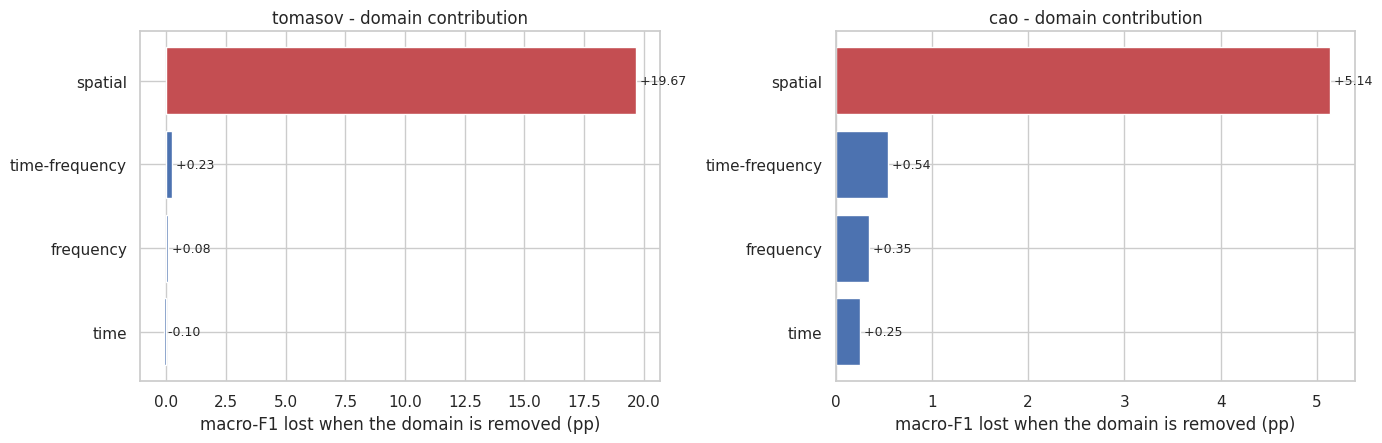

In [3]:
# Cost of removing each domain, relative to the full feature set.
cost = []
for ds in DATASETS:
    sub = lodo[lodo.dataset == ds].set_index("arm")
    ref = sub.loc["all 1002 (reference)", "f1_macro"]
    for arm in sub.index:
        if arm.startswith("no "):
            cost.append({"dataset": ds, "removed": arm.replace("no ", "").split(" (")[0],
                         "f1_without": sub.loc[arm, "f1_macro"],
                         "f1_full": ref,
                         "cost_pp": round(ref - sub.loc[arm, "f1_macro"], 2)})
cost = pd.DataFrame(cost).sort_values(["dataset", "cost_pp"], ascending=[True, False])
display(cost)
cost.to_csv(out_dir / "domain_removal_cost.csv", index=False)

fig, axes = plt.subplots(1, len(DATASETS), figsize=(7*len(DATASETS), 4.6))
axes = np.atleast_1d(axes)
for ax, ds in zip(axes, DATASETS):
    s = cost[cost.dataset == ds]
    ax.barh(s.removed, s.cost_pp, color=["#C44E52" if r == "spatial" else "#4C72B0"
                                          for r in s.removed])
    ax.set_xlabel("macro-F1 lost when the domain is removed (pp)")
    ax.set_title(f"{ds} - domain contribution")
    ax.invert_yaxis()
    for i, v in enumerate(s.cost_pp):
        ax.text(v, i, f" {v:+.2f}", va="center", fontsize=9)
plt.tight_layout(); plt.savefig(out_dir / "domain_removal_cost.png", dpi=200); plt.show()

## 2. Recording-identity probe - the decisive test

For each class that has **two or more recordings**, hold the class fixed and ask the
features to predict *which recording* the window came from.

The class label is constant within each probe, so any accuracy above chance is the
features identifying nuisance structure - fibre state, coupling, time of day - rather
than event type. The split is the same blocked split, so this is measured under exactly
the conditions the main model enjoys.

A domain that identifies the recording almost perfectly is a fingerprint. That is the
mechanism by which a within-recording split can flatter a model.

In [4]:
PROBE_ARMS = {"time": ["time"], "freq": ["freq"], "tf": ["tf"], "spatial": ["spatial"],
              "all": list(DOMAIN_SLICES)}

def group_column(ds, mani):
    if ds == "tomasov":
        return "recording_id" if "recording_id" in mani.columns else "stem"
    return "date"          # Cao: acquisition date is the analogous nuisance variable

probe = []
for ds in DATASETS:
    d = DATA[ds]
    mani = d["manifest"]
    gcol = group_column(ds, mani)
    groups = mani[gcol].to_numpy()
    y, sp = d["y"], d["split"]

    counts = pd.DataFrame({"label": y, "g": groups}).groupby("label").g.nunique()
    multi = counts[counts >= 2].index.tolist()
    print(f"\n=== {ds}: classes with >=2 {gcol} values: {multi} ===")

    for cls in multi:
        m = y == cls
        idx = np.flatnonzero(m)
        if len(idx) > PROBE_PER_CLASS:
            rng = np.random.default_rng(C.SEED)
            idx = np.sort(rng.choice(idx, PROBE_PER_CLASS, replace=False))
        gy, gsp = groups[idx], sp[idx]
        tr, te = gsp == "train", gsp == "test"
        if te.sum() < 30 or len(np.unique(gy[tr])) < 2 or len(np.unique(gy[te])) < 2:
            print(f"  {cls:14s} skipped (insufficient coverage)"); continue
        chance = 100 * pd.Series(gy[te]).value_counts(normalize=True).max()

        for aname, keep in PROBE_ARMS.items():
            c = cols(*keep)
            r = EV.fit_predict(MODEL, STRATEGY, d["X"][idx][tr][:, c], gy[tr],
                               d["X"][idx][te][:, c], gy[te], C.SEED)
            probe.append({"dataset": ds, "class": cls, "domain": aname,
                          "n_groups": int(len(np.unique(gy))),
                          "recording_id_accuracy": 100*r["metrics"]["accuracy"],
                          "majority_chance": round(chance, 2),
                          "above_chance_pp": round(100*r["metrics"]["accuracy"] - chance, 2)})
        row = [p for p in probe if p["class"] == cls and p["dataset"] == ds]
        got = {p["domain"]: p["recording_id_accuracy"] for p in row}
        print(f"  {cls:14s} chance {chance:5.1f}%  " +
              "  ".join(f"{k}={v:5.1f}" for k, v in got.items()), flush=True)

probe = pd.DataFrame(probe)
display(probe.round(2))
probe.to_csv(out_dir / "recording_identity_probe.csv", index=False)


=== tomasov: classes with >=2 recording_id values: ['car', 'fence', 'longboard', 'walk'] ===


/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_classificati

  car            chance  78.3%  time= 78.7  freq= 76.7  tf= 77.5  spatial= 97.2  all= 98.8


/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


  fence          chance  48.8%  time= 60.6  freq= 62.4  tf= 60.6  spatial= 85.0  all= 86.4
  longboard      skipped (insufficient coverage)
  walk           chance  78.2%  time= 69.8  freq= 68.7  tf= 72.5  spatial= 61.7  all= 62.0

=== cao: classes with >=2 date values: ['background', 'dig', 'knock', 'shake', 'walk', 'water'] ===


...

  walk           chance  61.6%  time= 90.5  freq= 77.2  tf= 92.7  spatial= 95.7  all= 97.0


/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: U

  water          chance  21.1%  time= 73.9  freq= 70.2  tf= 77.1  spatial= 84.4  all= 85.8


/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,dataset,class,domain,n_groups,recording_id_accuracy,majority_chance,above_chance_pp
0,tomasov,car,time,4,78.66,78.26,0.40
1,tomasov,car,freq,4,76.68,78.26,-1.58
2,tomasov,car,tf,4,77.47,78.26,-0.79
3,tomasov,car,spatial,4,97.23,78.26,18.97
4,tomasov,car,all,4,98.81,78.26,20.55
5,tomasov,fence,time,3,60.56,48.83,11.74
6,tomasov,fence,freq,3,62.44,48.83,13.62
7,tomasov,fence,tf,3,60.56,48.83,11.74
8,tomasov,fence,spatial,3,84.98,48.83,36.15
9,tomasov,fence,all,3,86.38,48.83,37.56


,dataset,domain,mean_id_accuracy,mean_above_chance
0,cao,all,90.39,40.49
2,cao,spatial,87.86,37.96
3,cao,tf,79.17,29.27
4,cao,time,75.73,25.82
1,cao,freq,67.04,17.14
5,tomasov,all,82.40,13.98
7,tomasov,spatial,81.31,12.89
8,tomasov,tf,70.18,1.76
9,tomasov,time,69.68,1.26
6,tomasov,freq,69.28,0.87


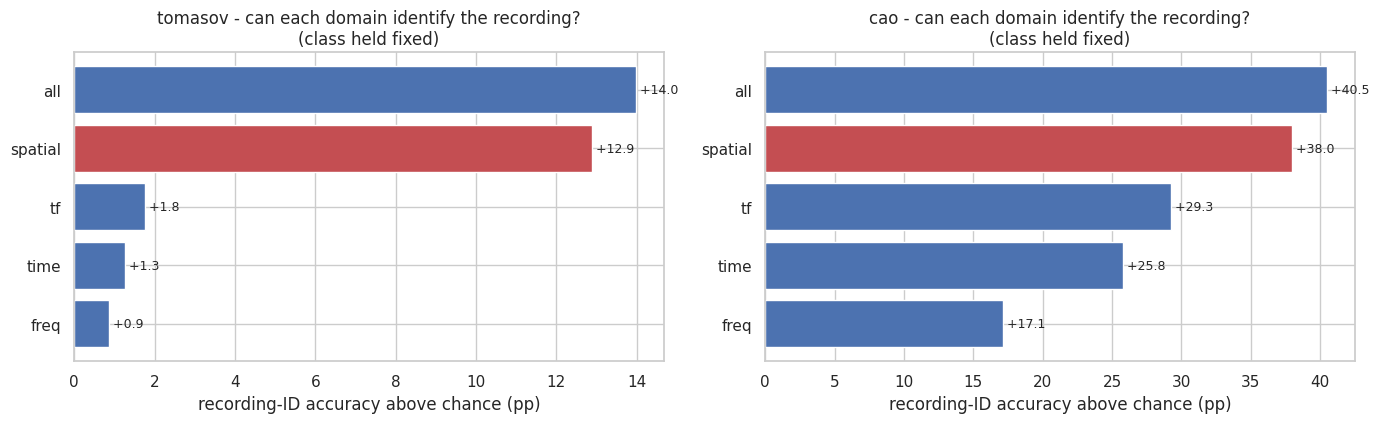

In [5]:
if len(probe):
    summ = (probe.groupby(["dataset", "domain"])
                 .agg(mean_id_accuracy=("recording_id_accuracy", "mean"),
                      mean_above_chance=("above_chance_pp", "mean"))
                 .reset_index().sort_values(["dataset", "mean_above_chance"], ascending=[True, False]))
    display(summ.round(2))
    summ.to_csv(out_dir / "recording_probe_summary.csv", index=False)

    fig, axes = plt.subplots(1, len(DATASETS), figsize=(7*len(DATASETS), 4.4))
    axes = np.atleast_1d(axes)
    for ax, ds in zip(axes, DATASETS):
        s = summ[summ.dataset == ds]
        ax.barh(s.domain, s.mean_above_chance,
                color=["#C44E52" if d == "spatial" else "#4C72B0" for d in s.domain])
        ax.set_xlabel("recording-ID accuracy above chance (pp)")
        ax.set_title(f"{ds} - can each domain identify the recording?\n(class held fixed)")
        ax.invert_yaxis()
        for i, v in enumerate(s.mean_above_chance):
            ax.text(v, i, f" {v:+.1f}", va="center", fontsize=9)
    plt.tight_layout(); plt.savefig(out_dir / "recording_identity_probe.png", dpi=200); plt.show()

## 3. Positional leakage check

`read_patch` centres the 32-channel window on the annotated locus, so within-patch
position should carry no absolute information. The exception is loci near the fibre ends,
where the window is clipped and the event is no longer centred. This checks whether
spatial feature values track the absolute locus index.

In [6]:
if "tomasov" in DATASETS:
    d = DATA["tomasov"]
    mani = d["manifest"]
    if "locus" in mani.columns:
        locus = mani["locus"].to_numpy().astype(float)
        names = np.array(d["feature_names"])
        sl = DOMAIN_SLICES["spatial"]
        Xs = d["X"][:, sl]
        r = np.array([abs(np.corrcoef(Xs[:, j], locus)[0, 1]) if Xs[:, j].std() > 0 else 0.0
                      for j in range(Xs.shape[1])])
        r = np.nan_to_num(r)
        top = pd.DataFrame({"feature": names[sl], "abs_corr_with_locus": r})                 .sort_values("abs_corr_with_locus", ascending=False)
        display(top.head(12).round(3))
        top.to_csv(out_dir / "spatial_vs_locus_correlation.csv", index=False)

        n_loci = int(mani["n_loci"].iloc[0]) if "n_loci" in mani.columns else int(locus.max()) + 1
        half = C.TOMASOV.patch_channels // 2
        n_edge = int(((locus < half) | (locus > n_loci - half)).sum())
        print(f"\nmax |corr| with absolute locus: {r.max():.3f}")
        print(f"windows within 16 loci of a fibre end (patch not centred): "
              f"{n_edge:,} / {len(locus):,} ({100*n_edge/len(locus):.2f}%)")
        print("A high correlation would mean spatial features encode WHERE on the fibre")
        print("the event sits, which for single-recording classes is the class itself.")

,feature,abs_corr_with_locus
50,SPAT:st_grad_c_energy,0.602
55,SPAT:st_grad_c_mean,0.523
53,SPAT:st_edge_density_c,0.272
34,SPAT:st_entropy,0.242
21,SPAT:sp_edge_density,0.239
32,SPAT:st_kurt,0.186
31,SPAT:st_skew,0.177
40,SPAT:st_t_entropy,0.171
38,SPAT:st_burstiness,0.166
52,SPAT:st_edge_density_t,0.161



max |corr| with absolute locus: 0.602
windows within 16 loci of a fibre end (patch not centred): 0 / 172,458 (0.00%)
A high correlation would mean spatial features encode WHERE on the fibre
the event sits, which for single-recording classes is the class itself.


## 4. Leave-one-recording-out, with and without spatial

The generalisation test that matters. Restricted to classes with >= 2 recordings, so a
held-out recording still leaves training data for its class.

If spatial features are a recording fingerprint, dropping them should **improve**
cross-recording accuracy - the model loses a shortcut it could not have used anyway.

In [7]:
loro = []
if "tomasov" in DATASETS:
    d = DATA["tomasov"]
    mani = d["manifest"]
    gcol = group_column("tomasov", mani)
    rec = mani[gcol].to_numpy()
    y = d["y"]

    counts = pd.DataFrame({"label": y, "g": rec}).groupby("label").g.nunique()
    multi = counts[counts >= 2].index.tolist()
    keep_rows = np.isin(y, multi)
    idx = np.flatnonzero(keep_rows)

    rng = np.random.default_rng(C.SEED)
    balanced = []
    for cls in multi:
        ci = idx[y[idx] == cls]
        balanced.append(rng.choice(ci, min(LORO_PER_CLASS, len(ci)), replace=False))
    idx = np.sort(np.concatenate(balanced))
    ys, recs = y[idx], rec[idx]
    print(f"LORO subset: {len(idx):,} windows, {len(multi)} classes, "
          f"{len(np.unique(recs))} recordings")

    for arm, keep in [("with spatial (1002)", list(DOMAIN_SLICES)),
                      ("without spatial (941)", ["time", "freq", "tf"])]:
        c = cols(*keep)
        accs = []
        for held in sorted(pd.unique(recs)):
            te = recs == held
            tr = ~te
            if te.sum() < 30 or len(np.unique(ys[tr])) < 2:
                continue
            r = EV.fit_predict(MODEL, STRATEGY, d["X"][idx][tr][:, c], ys[tr],
                               d["X"][idx][te][:, c], ys[te], C.SEED)
            a = 100*r["metrics"]["accuracy"]
            accs.append(a)
            loro.append({"arm": arm, "held_out": held[:36], "true_class": ys[te][0],
                         "n_test": int(te.sum()), "accuracy": a})
        print(f"  {arm:24s} mean {np.mean(accs):6.2f}%  sd {np.std(accs):5.2f}", flush=True)

loro = pd.DataFrame(loro)
if len(loro):
    display(loro.round(2))
    loro.to_csv(out_dir / "loro_with_without_spatial.csv", index=False)
    piv = loro.pivot(index="held_out", columns="arm", values="accuracy")
    piv["delta_pp"] = (piv["without spatial (941)"] - piv["with spatial (1002)"]).round(2)
    display(piv.round(2))
    print(f"\nmean change from dropping spatial: {piv.delta_pp.mean():+.2f} pp")
    print("A POSITIVE mean means spatial features were hurting cross-recording")
    print("generalisation, i.e. acting as a within-recording shortcut.")

LORO subset: 24,000 windows, 4 classes, 11 recordings


/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py

  with spatial (1002)      mean  63.10%  sd 23.38


/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py

  without spatial (941)    mean  44.02%  sd 15.51


/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/agx_orin/anaconda3/envs/jetson_torch/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,arm,held_out,true_class,n_test,accuracy
0,with spatial (1002),auto2_2023-04-17T124510+0100,car,205,84.88
1,with spatial (1002),auto4_2023-06-06T144655+0100,car,610,98.52
2,with spatial (1002),auto4_2023-06-06T145055+0100,car,4084,69.29
3,with spatial (1002),auto_2023-04-17T124152+0100,car,1101,32.24
4,with spatial (1002),fence_2023-04-17T123117+0100,fence,142,40.14
5,with spatial (1002),kopani_plot_2023-11-07T150207Z,fence,3672,80.96
6,with spatial (1002),longboard_2023-04-17T123543+0100,longboard,3965,28.47
7,with spatial (1002),longboardroad_2023-04-17T123638+0100,longboard,2035,36.46
8,with spatial (1002),plot_2023-11-07T150119Z,fence,2186,84.45
9,with spatial (1002),walking2_2023-04-17T122153+0100,walk,4601,67.57


arm,with spatial (1002),without spatial (941),delta_pp
held_out,,,
auto2_2023-04-17T124510+0100,84.88,62.93,-21.95
auto4_2023-06-06T144655+0100,98.52,52.79,-45.74
auto4_2023-06-06T145055+0100,69.29,11.53,-57.76
auto_2023-04-17T124152+0100,32.24,50.14,17.89
fence_2023-04-17T123117+0100,40.14,41.55,1.41
kopani_plot_2023-11-07T150207Z,80.96,20.29,-60.68
longboard_2023-04-17T123543+0100,28.47,59.24,30.77
longboardroad_2023-04-17T123638+0100,36.46,52.58,16.12
plot_2023-11-07T150119Z,84.45,42.91,-41.54



mean change from dropping spatial: -19.08 pp
A POSITIVE mean means spatial features were hurting cross-recording
generalisation, i.e. acting as a within-recording shortcut.


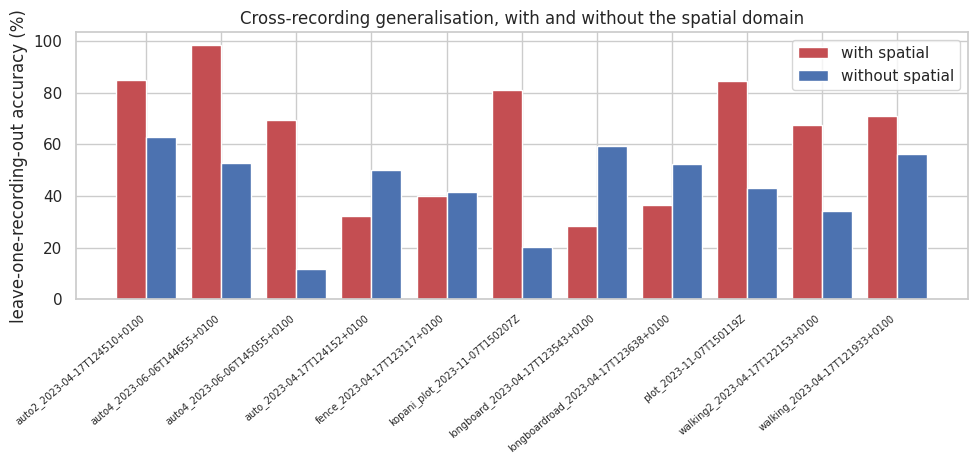

In [8]:
if len(loro):
    fig, ax = plt.subplots(figsize=(10, 4.8))
    x = np.arange(len(piv))
    ax.bar(x - 0.2, piv["with spatial (1002)"], 0.4, label="with spatial", color="#C44E52")
    ax.bar(x + 0.2, piv["without spatial (941)"], 0.4, label="without spatial", color="#4C72B0")
    ax.set_xticks(x); ax.set_xticklabels(piv.index, rotation=40, ha="right", fontsize=7)
    ax.set_ylabel("leave-one-recording-out accuracy (%)")
    ax.set_title("Cross-recording generalisation, with and without the spatial domain")
    ax.legend(); plt.tight_layout()
    plt.savefig(out_dir / "loro_with_without_spatial.png", dpi=200, bbox_inches="tight")
    plt.show()

## 5. Verdict

Mechanical reading of the four experiments. The thresholds are deliberate and stated so
the conclusion is not a judgement call.

In [9]:
verdict = {}
for ds in DATASETS:
    sub = lodo[lodo.dataset == ds].set_index("arm")
    spatial_cost = float(sub.loc["all 1002 (reference)", "f1_macro"]
                         - sub.loc["no spatial (941)", "f1_macro"])
    spatial_alone = float(sub.loc["spatial ONLY (61)", "f1_macro"])
    if len(probe) and "dataset" in probe.columns:
        p = probe[(probe.dataset == ds) & (probe.domain == "spatial")]
        id_above_chance = float(p.above_chance_pp.mean()) if len(p) else float("nan")
    else:
        id_above_chance = float("nan")

    if spatial_cost < 2.0:
        v = "CLEAN - spatial contributes little; keep the current framing"
    elif id_above_chance > 25.0:
        v = ("CONFOUNDED - spatial is load-bearing AND identifies the recording; "
             "report the non-spatial number as the headline")
    elif np.isnan(id_above_chance):
        v = "UNDETERMINED - not enough multi-recording classes to run the probe"
    else:
        v = ("GENUINE - spatial is load-bearing but does not identify the recording; "
             "report it as a substantive finding")

    verdict[ds] = {
        "spatial_removal_cost_pp": round(spatial_cost, 2),
        "spatial_only_f1": round(spatial_alone, 2),
        "spatial_recording_id_above_chance_pp": round(id_above_chance, 2)
                if not np.isnan(id_above_chance) else None,
        "headline_f1_if_confounded": round(float(sub.loc["no spatial (941)", "f1_macro"]), 2),
        "verdict": v,
    }
    print(f"\n=== {ds} ===")
    for k, val in verdict[ds].items():
        print(f"  {k:38s} {val}")

if len(loro):
    verdict["loro_delta_pp_dropping_spatial"] = float(piv.delta_pp.mean())

(out_dir / "verdict.json").write_text(json.dumps(verdict, indent=2), encoding="utf-8")
print("\nwritten:", out_dir / "verdict.json")


=== tomasov ===
  spatial_removal_cost_pp                19.67
  spatial_only_f1                        75.56
  spatial_recording_id_above_chance_pp   12.89
  headline_f1_if_confounded              62.13
  verdict                                GENUINE - spatial is load-bearing but does not identify the recording; report it as a substantive finding

=== cao ===
  spatial_removal_cost_pp                5.14
  spatial_only_f1                        95.55
  spatial_recording_id_above_chance_pp   37.96
  headline_f1_if_confounded              93.75
  verdict                                CONFOUNDED - spatial is load-bearing AND identifies the recording; report the non-spatial number as the headline

written: /mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Results/shared/12_spatial_ablation/verdict.json


In [10]:
final = pd.DataFrame([
    {"dataset": ds,
     "full 1002 macro-F1": lodo[(lodo.dataset==ds) & (lodo.arm=="all 1002 (reference)")].f1_macro.iloc[0],
     "no-spatial 941 macro-F1": lodo[(lodo.dataset==ds) & (lodo.arm=="no spatial (941)")].f1_macro.iloc[0],
     "spatial-only macro-F1": lodo[(lodo.dataset==ds) & (lodo.arm=="spatial ONLY (61)")].f1_macro.iloc[0],
     "spatial recording-ID above chance (pp)": verdict[ds]["spatial_recording_id_above_chance_pp"],
     "verdict": verdict[ds]["verdict"].split(" - ")[0]}
    for ds in DATASETS
])
display(final.round(2))
final.to_csv(C.results_dir("shared", "tables") / "spatial_ablation_summary.csv", index=False)

,dataset,full 1002 macro-F1,no-spatial 941 macro-F1,spatial-only macro-F1,spatial recording-ID above chance (pp),verdict
0,tomasov,81.81,62.13,75.56,12.89,GENUINE
1,cao,98.89,93.75,95.55,37.96,CONFOUNDED


---
### Sentence to paste into the paper, depending on the verdict

**CLEAN**
> Removing the spatial and spatio-temporal descriptors costs only X pp of macro-F1,
> confirming that the reported performance does not depend on recording-specific fibre
> geometry.

**CONFOUNDED**
> The spatial descriptors carry a disproportionate share of the model's decision, and a
> probe in which the event class is held fixed shows they identify the source recording
> X pp above chance. Because five of the nine classes originate from a single recording,
> these features can act as a proxy for class identity. We therefore report the
> 941-feature signal-agnostic configuration (X% macro-F1) as the operational result, and
> treat the full 1,002-feature figure as an upper bound attainable only when the
> deployment recording is represented in training.

**GENUINE**
> Although the spatial descriptors dominate feature importance, they do not identify the
> source recording above chance once the event class is fixed, indicating that they encode
> event-specific propagation structure rather than recording-specific nuisance.

After this runs, Sections IV-V can be written against a settled claim.